
# Comparação RoTHP vs THP no Dataset StackOverflow

Neste notebook, testaremos os modelos no dataset **StackOverflow**, que possui dinâmicas de tempo real e é mais leve que o Retweet.

Compararemos:
1. **RoTHP Original**: Apenas RoPE na atenção.
2. **RoTHP Hybrid**: RoPE na atenção + Embedding Absoluto na entrada.
3. **THP Tradicional**: Apenas Embedding Absoluto.


In [1]:

import sys
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset

project_root = '/Users/hugoramossoares/Sites/EasyTemporalPointProcess'
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Import Models
from easy_tpp.model.torch_model.torch_rothp import RoTHP
from easy_tpp.model.torch_model.torch_rothp_hybrid import RoTHPHybrid
from easy_tpp.model.torch_model.torch_thp import THP

print("Bibliotecas carregadas.")


Bibliotecas carregadas.


In [2]:

# =============================================================================
# CARREGAR DATASET (StackOverflow via HuggingFace)
# =============================================================================
print("Carregando dataset 'easytpp/stackoverflow'...")
dataset = load_dataset("easytpp/stackoverflow")

train_data = dataset['train']
dev_data = dataset['validation']
test_data = dataset['test']

print(f"\nDataset StackOverflow carregado!")
print(f"Treino: {len(train_data)} sequências")
print(f"Dev:    {len(dev_data)} sequências")
print(f"Teste:  {len(test_data)} sequências")

# Verificar metadados do primeiro exemplo
sample = train_data[0]
print("\nExemplo de sequência:")
print(f"Event Types: {sample['type_event'][:10]}...")
print(f"Time deltas: {sample['time_since_last_event'][:10]}...")
print(f"Dim Process (Num Event Types): {sample['dim_process']}")


Carregando dataset 'easytpp/stackoverflow'...

Dataset StackOverflow carregado!
Treino: 1401 sequências
Dev:    401 sequências
Teste:  401 sequências

Exemplo de sequência:
Event Types: [5, 13, 3, 3, 2, 3, 3, 5, 13, 7]...
Time deltas: [0.0, 0.0018310546875, 4.2149658203125, 0.4339599609375, 0.0513916015625, 3.716064453125, 0.27783203125, 0.6956787109375, 0.0093994140625, 0.8785400390625]...
Dim Process (Num Event Types): 22


In [3]:

# =============================================================================
# PREPARAÇÃO DE BATCH (Adaptado para formato HuggingFace)
# =============================================================================
def collate_fn(batch_list):
    """Converte lista de dicts (HF) para tensores de batch do EasyTPP."""
    time_seqs = []
    time_delta_seqs = []
    type_seqs = []
    
    max_len = 0
    for item in batch_list:
        # Converter listas python para tensores, se necessário
        ts = item['time_since_start']
        td = item['time_since_last_event']
        ev = item['type_event']
        
        if len(ts) > max_len:
            max_len = len(ts)
            
        time_seqs.append(torch.tensor(ts, dtype=torch.float32))
        time_delta_seqs.append(torch.tensor(td, dtype=torch.float32))
        type_seqs.append(torch.tensor(ev, dtype=torch.long))

    batch_size = len(batch_list)
    
    # Padding
    pad_time = torch.zeros(batch_size, max_len)
    pad_delta = torch.zeros(batch_size, max_len)
    pad_type = torch.zeros(batch_size, max_len, dtype=torch.long)
    attention_mask = torch.zeros(batch_size, max_len, max_len) # mask de atenção pad
    batch_non_pad_mask = torch.zeros(batch_size, max_len)
    
    for i in range(batch_size):
        l = len(time_seqs[i])
        pad_time[i, :l] = time_seqs[i]
        pad_delta[i, :l] = time_delta_seqs[i]
        pad_type[i, :l] = type_seqs[i]
        batch_non_pad_mask[i, :l] = 1
        
        # Causal Mask (Triangular Superior)
        causal_mask = torch.tril(torch.ones(l, l))
        attention_mask[i, :l, :l] = causal_mask

    return (pad_time, pad_delta, pad_type, batch_non_pad_mask, attention_mask)

# Teste rápido do Collate
sample_batch = [train_data[0], train_data[1]]
batch_tensors = collate_fn(sample_batch)
print("Batch Tensors Shapes:", [t.shape for t in batch_tensors])


Batch Tensors Shapes: [torch.Size([2, 78]), torch.Size([2, 78]), torch.Size([2, 78]), torch.Size([2, 78]), torch.Size([2, 78, 78])]


In [4]:

# =============================================================================
# CONFIGURAÇÃO DO MODELO
# =============================================================================

class ModelConfig:
    def __init__(self, hidden_size=64, num_heads=4, num_layers=2):
        self.hidden_size = hidden_size
        self.time_emb_size = hidden_size
        self.num_layers = num_layers
        self.num_heads = num_heads
        self.dropout_rate = 0.1
        self.use_ln = True
        
        # StackOverflow Specs
        self.num_event_types = 22     # 22 tipos de badges
        self.num_event_types_pad = 23 # +1 para pad
        self.pad_token_id = 22
        
        self.loss_integral_num_sample_per_step = 20
        self.use_mc_samples = False
        self.gpu = -1 # CPU por enquanto
        self.thinning = None

def train_eval_loop(model_class, name, config, train_ds, test_ds, epochs=5, batch_size=32, lr=1e-3):
    print(f"\n>>> Iniciando Treinamento: {name}")
    torch.manual_seed(42)
    model = model_class(config)
    
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    
    history = []
    
    for epoch in range(1, epochs+1):
        # Treino
        model.train()
        total_loss = 0
        total_events = 0
        
        indices = np.random.permutation(len(train_ds))
        max_batches = 200 
        
        for i in range(0, len(indices), batch_size):
            if i // batch_size > max_batches: break
            
            batch_idx = indices[i:i+batch_size]
            
            batch_list = [train_ds[int(k)] for k in batch_idx]
            batch_data = collate_fn(batch_list)
            
            optimizer.zero_grad()
            loss, num_events = model.loglike_loss(batch_data)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            total_loss += loss.item()
            total_events += num_events
            
        nll_train = total_loss / (total_events + 1e-9)
        
        # Avaliação
        model.eval()
        with torch.no_grad():
            test_subset = [test_ds[i] for i in range(min(500, len(test_ds)))]
            batch_test = collate_fn(test_subset)
            loss_test, num_test = model.loglike_loss(batch_test)
            nll_test = (loss_test / num_test).item()
        
        print(f"  Ep {epoch} | Train NLL: {nll_train:.4f} | Test NLL: {nll_test:.4f}")
        history.append(nll_test)
        
    return history


In [5]:

# =============================================================================
# EXECUÇÃO COMPARATIVA
# =============================================================================

# Configuração Moderada (2 Layers, 64 Hidden)
config = ModelConfig(hidden_size=64, num_heads=4, num_layers=2)

# 1. RoTHP Original
hist_rothp = train_eval_loop(RoTHP, "RoTHP Original", config, train_data, test_data, epochs=300)

# 2. RoTHP Híbrido
hist_hybrid = train_eval_loop(RoTHPHybrid, "RoTHP Hybrid", config, train_data, test_data, epochs=300)

# 3. THP Tradicional
hist_thp = train_eval_loop(THP, "THP Tradicional", config, train_data, test_data, epochs=300)



>>> Iniciando Treinamento: RoTHP Original
  Ep 1 | Train NLL: 3.8299 | Test NLL: 2.2116
  Ep 2 | Train NLL: 1.5235 | Test NLL: 0.5814
  Ep 3 | Train NLL: 0.1008 | Test NLL: -0.1314
  Ep 4 | Train NLL: -0.2460 | Test NLL: -0.5049
  Ep 5 | Train NLL: -0.4710 | Test NLL: -0.7394
  Ep 6 | Train NLL: -0.8448 | Test NLL: -1.0547
  Ep 7 | Train NLL: -1.2034 | Test NLL: -1.3022
  Ep 8 | Train NLL: -0.6664 | Test NLL: -0.9360
  Ep 9 | Train NLL: -0.9768 | Test NLL: -1.3233
  Ep 10 | Train NLL: -1.1106 | Test NLL: -1.4378
  Ep 11 | Train NLL: -1.3871 | Test NLL: -1.2459
  Ep 12 | Train NLL: -1.4222 | Test NLL: -1.5133
  Ep 13 | Train NLL: -1.5650 | Test NLL: -1.5877
  Ep 14 | Train NLL: -0.9461 | Test NLL: -1.6312
  Ep 15 | Train NLL: -1.4261 | Test NLL: -1.4380
  Ep 16 | Train NLL: -0.6470 | Test NLL: -1.5913
  Ep 17 | Train NLL: -1.0590 | Test NLL: -0.7059
  Ep 18 | Train NLL: -0.7058 | Test NLL: -0.7018
  Ep 19 | Train NLL: -1.3611 | Test NLL: -1.3442
  Ep 20 | Train NLL: -1.3945 | Test NLL:

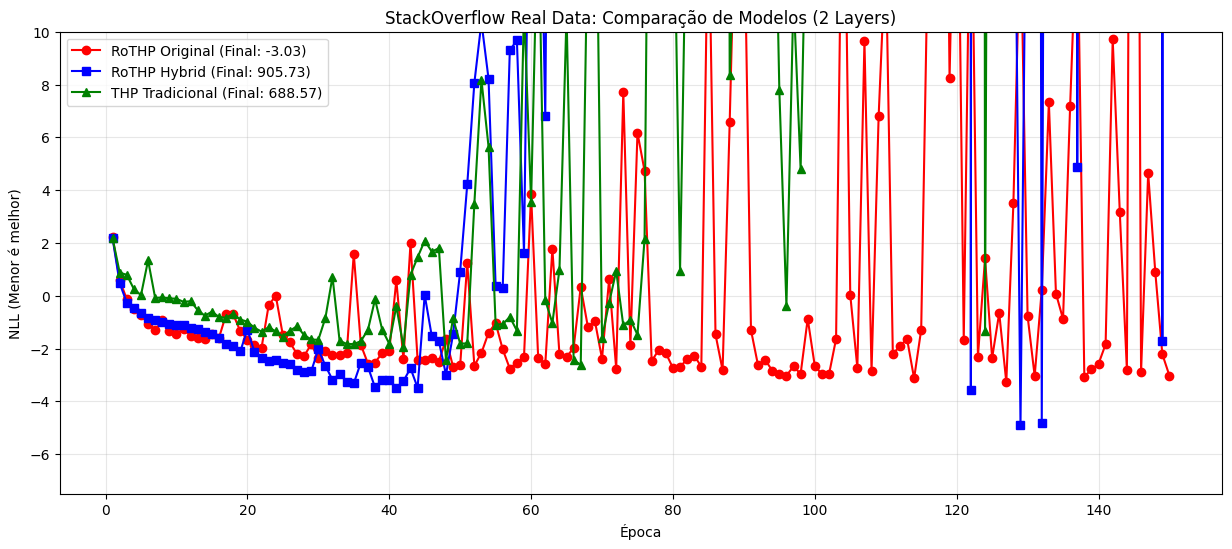

In [15]:
plt.figure(figsize=(15, 6))

# Função auxiliar para plotar dinamicamente
def plot_robust(hist, label, style):
    if hist and len(hist) > 0:
        epochs = range(1, len(hist) + 1)
        final_val = hist[-1]
        plt.plot(epochs, hist, style, label=f'{label} (Final: {final_val:.2f})')

# Plotar se as variáveis existirem
if 'hist_rothp' in locals(): plot_robust(hist_rothp, 'RoTHP Original', 'r-o')
if 'hist_hybrid' in locals(): plot_robust(hist_hybrid, 'RoTHP Hybrid', 'b-s')
if 'hist_thp' in locals(): plot_robust(hist_thp, 'THP Tradicional', 'g-^')

plt.xlabel('Época')
plt.ylabel('NLL (Menor é melhor)')
plt.title('StackOverflow Real Data: Comparação de Modelos (2 Layers)')
plt.legend()
plt.grid(True, alpha=0.3)
# Limit Y-axis to ignore extreme outliers
plt.ylim(top=10)
plt.ylim(bottom=-7.5)
plt.show()
